In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("../Week 1/adult_cleaned.csv")

In [3]:
features = [
    "age",
    "education_num",
    "capital_gain",
    "capital_loss",
    "hours_per_week"
]

X = df[features].copy()

print(X.head())

   age  education_num  capital_gain  capital_loss  hours_per_week
0   39             13          2174             0              40
1   50             13             0             0              13
2   38              9             0             0              40
3   53              7             0             0              40
4   28             13             0             0              40


In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Standardization completed.")

Standardization completed.


In [5]:
inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

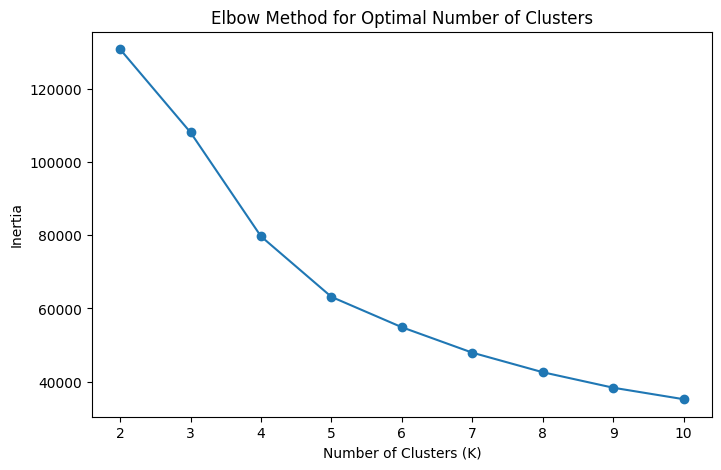

In [6]:
plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker="o")

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.show()

In [7]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters

print(df["cluster"].value_counts().sort_index())

cluster
0     1484
1    15475
2    15419
3      159
Name: count, dtype: int64


In [8]:
silhouette = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", round(silhouette, 4))

Silhouette Score: 0.2589


In [9]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.25933255 0.20604848]


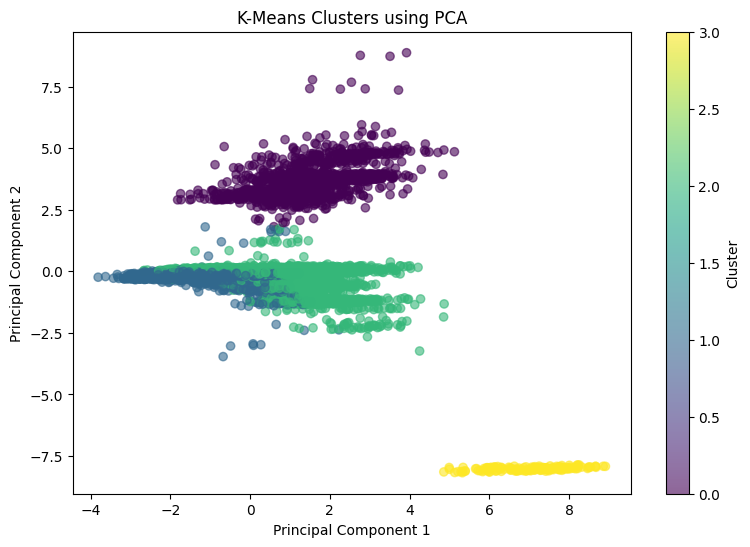

In [10]:
plt.figure(figsize=(9,6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    alpha=0.6
)

plt.title("K-Means Clusters using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

In [11]:
cluster_summary = df.groupby("cluster")[features].mean()

print(cluster_summary)

               age  education_num  capital_gain  capital_loss  hours_per_week
cluster                                                                      
0        41.634097      10.988544      0.000000   1901.707547       43.357143
1        28.164911       9.367690    211.984685      0.408271       36.705202
2        48.670471      10.682016   1031.780271      0.924055       43.811791
3        46.358491      12.918239  99999.000000      0.000000       49.798742


In [12]:
cluster_size = df["cluster"].value_counts().sort_index()

print("Cluster Sizes:")
print(cluster_size)

Cluster Sizes:
cluster
0     1484
1    15475
2    15419
3      159
Name: count, dtype: int64


In [13]:
for cluster in sorted(df["cluster"].unique()):
    
    print("\nCluster", cluster)
    print("-" * 30)
    
    print("Number of individuals:",
          (df["cluster"] == cluster).sum())
    
    print(df[df["cluster"] == cluster][features].mean())


Cluster 0
------------------------------
Number of individuals: 1484
age                 41.634097
education_num       10.988544
capital_gain         0.000000
capital_loss      1901.707547
hours_per_week      43.357143
dtype: float64

Cluster 1
------------------------------
Number of individuals: 15475
age                28.164911
education_num       9.367690
capital_gain      211.984685
capital_loss        0.408271
hours_per_week     36.705202
dtype: float64

Cluster 2
------------------------------
Number of individuals: 15419
age                 48.670471
education_num       10.682016
capital_gain      1031.780271
capital_loss         0.924055
hours_per_week      43.811791
dtype: float64

Cluster 3
------------------------------
Number of individuals: 159
age                  46.358491
education_num        12.918239
capital_gain      99999.000000
capital_loss          0.000000
hours_per_week       49.798742
dtype: float64


income   <=50K    >50K
cluster               
0        48.05   51.95
1        91.74    8.26
2        63.48   36.52
3         0.00  100.00


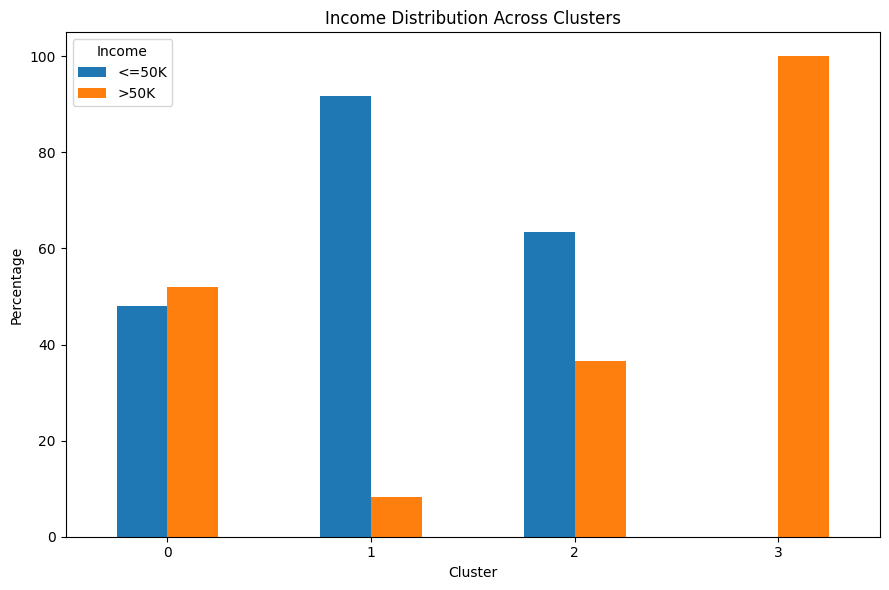

In [15]:
cluster_income = pd.crosstab(
    df["cluster"],
    df["income"],
    normalize="index"
) * 100

print(cluster_income.round(2))

cluster_income.plot(
    kind="bar",
    figsize=(9,6)
)

plt.title("Income Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Income")

plt.tight_layout()
plt.show()

In [16]:
print("FINAL CLUSTERING SUMMARY")
print("=" * 40)

print("Dataset shape:", df.shape)
print("Number of clusters:", df["cluster"].nunique())
print("Silhouette Score:", round(silhouette, 4))

print("\nCluster sizes:")
print(df["cluster"].value_counts().sort_index())

print("\nCluster means:")
print(cluster_summary)

FINAL CLUSTERING SUMMARY
Dataset shape: (32537, 16)
Number of clusters: 4
Silhouette Score: 0.2589

Cluster sizes:
cluster
0     1484
1    15475
2    15419
3      159
Name: count, dtype: int64

Cluster means:
               age  education_num  capital_gain  capital_loss  hours_per_week
cluster                                                                      
0        41.634097      10.988544      0.000000   1901.707547       43.357143
1        28.164911       9.367690    211.984685      0.408271       36.705202
2        48.670471      10.682016   1031.780271      0.924055       43.811791
3        46.358491      12.918239  99999.000000      0.000000       49.798742
